In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
import datasets as ds


In [2]:
METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
METEO_SWISS_MEAN_TEMP_GLOB = './datasets/MeteoSwiss/TabsD_v2.0_swiss.lv95/*.nc'
ERA5_MEAN_TEMP_GLOB = './datasets/ERA5_Land/temperature/*.nc'
PW_FIRST_DATE    = '2017-01-03'
PW_LAST_DATE     = '2024-12-31'
NAN_THRESHOLD    = 0.01   # keep stations with ≥99% valid days (≤1% NaN)


In [3]:
daily_tmax_pw, stations_meta, valid_stations = ds.load_peakweather_stations(
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
    validity_threshold=NAN_THRESHOLD,
    station_type=None,
)
print(f"PW stations retained: {len(valid_stations)}")
print(daily_tmax_pw.head())


Loading PeakWeather stations (None) from 2017-01-03 to 2024-12-31 ...
  191 / 302 stations pass validity threshold (1%)
  Daily tmax shape: (2919, 191)  (2017-01-03 → 2024-12-30)
  Altitude range: [203, 3571] m
PW stations retained: 191
nat_abbr    ABO  AIG  ALT  AND   ANT  ARH   ARO   ATT  BAS   BEH  ...  VSTRI  \
datetime                                                          ...          
2017-01-03  2.1  4.0  1.5  1.6  -1.0  1.7  -0.1  -3.7  1.5  -3.0  ...    2.3   
2017-01-04 -3.0  3.8  2.2 -1.1  -5.3  0.6  -5.1  -5.7  0.3  -3.9  ...   -2.4   
2017-01-05  3.3  3.1  3.1 -0.4  -2.8  3.0  -3.0  -5.2  2.0  -2.7  ...    3.3   
2017-01-06 -4.4  3.5  3.2 -2.7  -5.6  1.4  -9.1 -14.8  1.4 -11.3  ...   -4.0   
2017-01-07 -8.0 -1.4 -2.8 -7.1 -10.9 -4.1 -11.6  -8.6 -2.5 -11.3  ...  -10.3   

nat_abbr    VSTSN  VSTUR  VSVER  VSVIS  WAE   WFJ  WYN  ZER  ZWE  
datetime                                                          
2017-01-03    1.8   -0.1    3.5    2.9  1.4  -4.6  1.0  3.2  3.8  
2

In [4]:
from peakweather import PeakWeatherDataset
pw_ds_mean = PeakWeatherDataset(
    station_type=None,
    imputation_method=None,
    freq='D',
    aggregation_methods={'temperature': 'mean'},
)
df_mean = pw_ds_mean.get_observations(
    parameters=['temperature'],
    first_date=PW_FIRST_DATE,
    last_date=PW_LAST_DATE,
)
daily_tmean_pw = df_mean.xs('temperature', axis=1, level=1)
daily_tmean_pw.index = daily_tmean_pw.index.tz_localize(None)

daily_tmean_pw = daily_tmean_pw[valid_stations]


In [5]:
import glob as _glob
era5_ds = xr.open_mfdataset(sorted(_glob.glob(ERA5_MEAN_TEMP_GLOB)), combine='by_coords')
era5_dates_all = pd.DatetimeIndex(era5_ds['time'].values)
era5_lats = era5_ds['latitude'].values
era5_lons  = era5_ds['longitude'].values
print(f"ERA5 lat range: [{era5_lats.min():.1f}, {era5_lats.max():.1f}]")
print(f"ERA5 lon range: [{era5_lons.min():.1f}, {era5_lons.max():.1f}]")
print(f"ERA5 dates: {era5_dates_all[0].date()} → {era5_dates_all[-1].date()}, {len(era5_dates_all)} days")

ERA5 lat range: [45.4, 48.2]
ERA5 lon range: [5.0, 11.0]
ERA5 dates: 1960-01-01 → 2023-12-31, 23376 days


In [6]:
station_era5_cell = {}   # station_code -> (lat_idx, lon_idx)
for stn in valid_stations:
    stn_lat = stations_meta.loc[stn, 'latitude']
    stn_lon = stations_meta.loc[stn, 'longitude']
    lat_idx = int(np.argmin(np.abs(era5_lats - stn_lat)))
    lon_idx = int(np.argmin(np.abs(era5_lons - stn_lon)))
    station_era5_cell[stn] = (lat_idx, lon_idx)

print("Station → nearest ERA5 cell (first 5):")
for stn in valid_stations[:5]:
    lat_idx, lon_idx = station_era5_cell[stn]
    d_lat = abs(stations_meta.loc[stn, 'latitude']  - era5_lats[lat_idx])
    d_lon = abs(stations_meta.loc[stn, 'longitude'] - era5_lons[lon_idx])
    print(f"  {stn:8s}  Δlat={d_lat:.3f}°  Δlon={d_lon:.3f}°  → cell lat={era5_lats[lat_idx]:.1f} lon={era5_lons[lon_idx]:.1f}")

Station → nearest ERA5 cell (first 5):
  ABO       Δlat=0.008°  Δlon=0.039°  → cell lat=46.5 lon=7.6
  AIG       Δlat=0.027°  Δlon=0.024°  → cell lat=46.3 lon=6.9
  ALT       Δlat=0.013°  Δlon=0.022°  → cell lat=46.9 lon=8.6
  AND       Δlat=0.010°  Δlon=0.032°  → cell lat=46.6 lon=9.4
  ANT       Δlat=0.031°  Δlon=0.019°  → cell lat=46.6 lon=8.6


In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = np.radians([lat1, lon1, lat2, lon2])
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin((lon2-lon1)/2)**2
    return 6371.0 * 2 * np.arcsin(np.sqrt(a))

station_dist_km = {}
for stn in valid_stations:
    lat_idx, lon_idx = station_era5_cell[stn]
    station_dist_km[stn] = haversine_km(
        stations_meta.loc[stn, 'latitude'],  stations_meta.loc[stn, 'longitude'],
        era5_lats[lat_idx], era5_lons[lon_idx],
    )
print(f"Median station–ERA5 cell distance: {np.median(list(station_dist_km.values())):.1f} km")


Median station–ERA5 cell distance: 3.5 km


In [16]:
# Toggle this to test whether the 1-day shift improves alignment with ERA5
APPLY_DATE_SHIFT = True   # True = PW day D+1 paired with ERA5 day D

pw_tmean_aligned = daily_tmean_pw.copy()
if APPLY_DATE_SHIFT:
    pw_tmean_aligned.index = daily_tmean_pw.index - pd.Timedelta(days=1)

era5_cutoff        = pd.Timestamp('2023-12-31')
era5_dates_cut     = era5_dates_all[era5_dates_all <= era5_cutoff]
pw_dates_for_merge = pd.DatetimeIndex(pw_tmean_aligned.index.date.astype(str))
common_dates       = era5_dates_cut.intersection(pw_dates_for_merge)
print(f"{'With' if APPLY_DATE_SHIFT else 'Without'} shift → {len(common_dates)} common dates "
      f"({common_dates[0].date()} → {common_dates[-1].date()})")

def extract_era5_at_stations(era5_dataset, var_name, dates, stations, cell_map):
    """Extract ERA5 temperature at station cells, in °C."""
    out = np.full((len(dates), len(stations)), np.nan, dtype=np.float32)
    for j, stn in enumerate(stations):
        lat_idx, lon_idx = cell_map[stn]
        out[:, j] = (
            era5_dataset[var_name]
            .sel(time=dates)
            .isel(latitude=lat_idx, longitude=lon_idx)
            .values
            .astype(np.float32) - 273.15   # Kelvin → °C
        )
    return out

era5_tmean_at_stns = extract_era5_at_stations(
    era5_ds, 't2m', common_dates, valid_stations, station_era5_cell,
)
pw_tmean_at_stns = pw_tmean_aligned.loc[common_dates, valid_stations].values.astype(np.float32)

print(f"ERA5 array: {era5_tmean_at_stns.shape}")
print(f"PW   array: {pw_tmean_at_stns.shape}")


With shift → 2555 common dates (2017-01-02 → 2023-12-31)
ERA5 array: (2555, 191)
PW   array: (2555, 191)


In [17]:
def compute_station_errors(pw_vals_2d, ms_vals_2d, stations, stations_meta, min_days=30):
    records = []
    for j, stn in enumerate(stations):
        pw = pw_vals_2d[:, j]
        ms = ms_vals_2d[:, j]
        valid = ~np.isnan(pw) & ~np.isnan(ms)
        n_valid = int(valid.sum())
        if n_valid < min_days:
            continue
        diff = pw[valid] - ms[valid]
        records.append(dict(
            station      = stn,
            station_name = stations_meta.loc[stn, 'station_name'],
            latitude     = stations_meta.loc[stn, 'latitude'],
            longitude    = stations_meta.loc[stn, 'longitude'],
            altitude_m   = stations_meta.loc[stn, 'station_height'],
            dist_km      = round(station_dist_km[stn], 2),
            n_valid_days = n_valid,
            MAE          = float(np.mean(np.abs(diff))),
            RMSE         = float(np.sqrt(np.mean(diff**2))),
            Bias         = float(np.mean(diff)),
            Corr         = float(np.corrcoef(pw[valid], ms[valid])[0, 1]),
        ))
    return pd.DataFrame(records).sort_values('MAE').reset_index(drop=True)


results_tmean = compute_station_errors(pw_tmean_at_stns, era5_tmean_at_stns, valid_stations, stations_meta)
print(f"Stations: {len(results_tmean)}")
print(f"Median MAE:  {results_tmean['MAE'].median():.2f} °C")
print(f"Median Bias: {results_tmean['Bias'].median():.2f} °C")
print(f"Median Corr: {results_tmean['Corr'].median():.3f}")



Stations: 191
Median MAE:  3.09 °C
Median Bias: 2.16 °C
Median Corr: 0.973


In [18]:
display_cols = ['station', 'station_name', 'altitude_m', 'dist_km',
                'n_valid_days', 'MAE', 'RMSE', 'Bias', 'Corr']

print(f"\n{'='*70}")
print(f"  Daily Mean (Tmean) — PeakWeather vs ERA5")
print(f"{'='*70}")
with pd.option_context('display.max_rows', None, 'display.float_format', '{:.2f}'.format):
    print(results_tmean[display_cols].to_string(index=False))
print(f"\n  Median MAE:  {results_tmean['MAE'].median():.2f} °C")
print(f"  Median RMSE: {results_tmean['RMSE'].median():.2f} °C")
print(f"  Median Bias: {results_tmean['Bias'].median():.2f} °C")
print(f"  Median Corr: {results_tmean['Corr'].median():.3f}")



  Daily Mean (Tmean) — PeakWeather vs ERA5
station              station_name  altitude_m  dist_km  n_valid_days  MAE  RMSE  Bias  Corr
    FAH                      Fahy      596.39     4.08          2555 0.78  1.09  0.25  0.99
    MOE                    Möhlin      343.00     3.51          2554 0.82  1.03  0.35  0.99
    EGO                  Egolzwil      521.90     2.32          2554 0.89  1.16  0.01  0.99
    SHA              Schaffhausen      438.38     1.88          2555 0.90  1.08  0.50  0.99
    RUE                 Rünenberg      611.17     4.14          2555 0.90  1.22  0.32  0.99
    HLL                    Hallau      419.00     2.23          2555 0.92  1.19  0.06  0.99
    WYN                     Wynau      421.99     5.09          2555 0.93  1.17  0.04  0.99
    PFA             Pfäffikon, ZH      537.00     4.27           389 0.94  1.19  0.26  0.99
    KOP                  Koppigen      485.20     2.14          2555 0.95  1.20 -0.11  0.99
    CDF         La Chaux-de-Fonds   

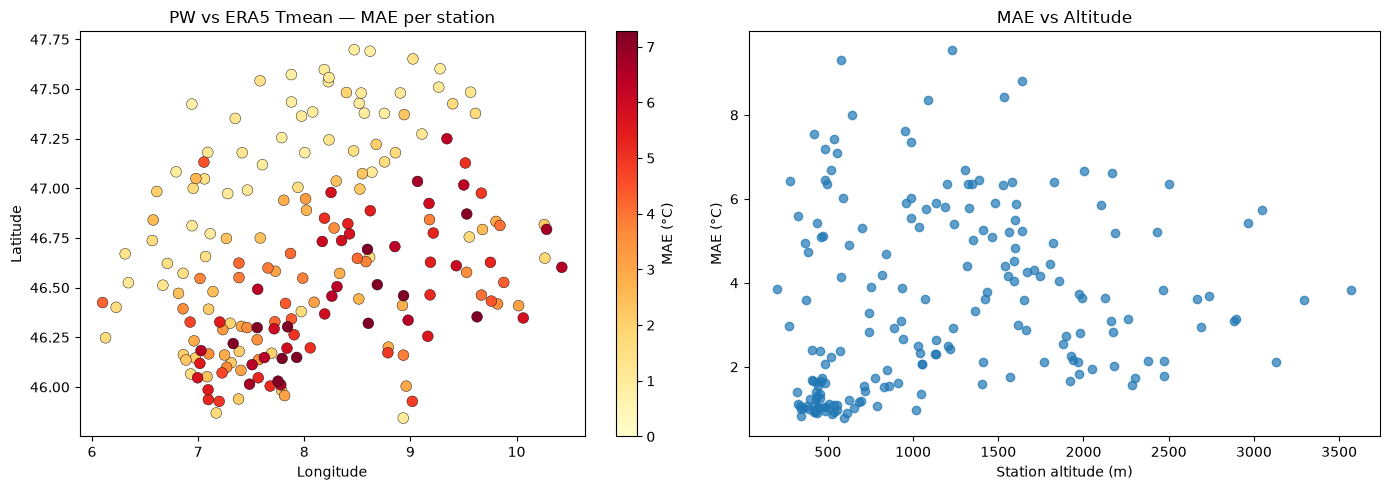

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vmax = results_tmean['MAE'].quantile(0.95)
sc = axes[0].scatter(results_tmean['longitude'], results_tmean['latitude'],
                     c=results_tmean['MAE'], cmap='YlOrRd', s=60,
                     vmin=0, vmax=vmax, edgecolors='k', linewidths=0.3)
plt.colorbar(sc, ax=axes[0], label='MAE (°C)')
axes[0].set_title(f'PW vs ERA5 Tmean — MAE per station')
axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

axes[1].scatter(results_tmean['altitude_m'], results_tmean['MAE'], alpha=0.7)
axes[1].set_xlabel('Station altitude (m)'); axes[1].set_ylabel('MAE (°C)')
axes[1].set_title('MAE vs Altitude')

plt.tight_layout()
plt.show()


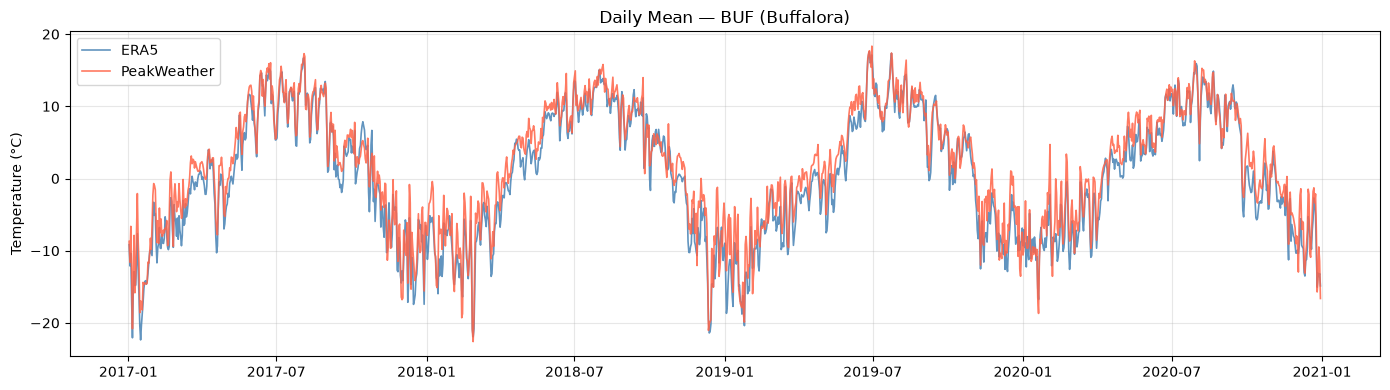

In [23]:
SELECTED_STATION = 'BUF'
PLOT_START_DATE  = '2017-01-01'
PLOT_END_DATE    = '2020-12-30'

j = valid_stations.index(SELECTED_STATION)
date_mask  = (common_dates >= PLOT_START_DATE) & (common_dates <= PLOT_END_DATE)
plot_dates = common_dates[date_mask]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(plot_dates, era5_tmean_at_stns[date_mask, j], color='steelblue', linewidth=1.2,
        label='ERA5', alpha=0.85)
ax.plot(plot_dates, pw_tmean_at_stns[date_mask, j],   color='tomato',    linewidth=1.2,
        label='PeakWeather', alpha=0.85)
ax.set_ylabel('Temperature (°C)')
ax.set_title(f'Daily Mean — {SELECTED_STATION} ({stations_meta.loc[SELECTED_STATION, "station_name"]})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [24]:
DIFF_THRESHOLD = 10.0   # °C

diff_tmean = pw_tmean_at_stns - era5_tmean_at_stns   # (n_dates, n_stations)
day_idxs, stn_idxs = np.where(np.abs(diff_tmean) >= DIFF_THRESHOLD)

records = []
for d, s in zip(day_idxs, stn_idxs):
    diff_val = diff_tmean[d, s]
    if np.isnan(diff_val):
        continue
    stn = valid_stations[s]
    records.append(dict(
        station      = stn,
        station_name = stations_meta.loc[stn, 'station_name'],
        date         = common_dates[d].date(),
        diff_degC    = round(float(diff_val), 2),   # positive = PW warmer than MeteoSwiss
    ))

large_diff_df = (
    pd.DataFrame(records)
    .sort_values('diff_degC', key=np.abs, ascending=False)
    .reset_index(drop=True)
)

print(f"Events with |ΔT| ≥ {DIFF_THRESHOLD}°C (daily mean, PW − MeteoSwiss): "
      f"{len(large_diff_df)}")
with pd.option_context('display.max_rows', None, 'display.float_format', '{:.2f}'.format):
    print(large_diff_df[['station', 'station_name', 'diff_degC', 'date']].to_string(index=False))


Events with |ΔT| ≥ 10.0°C (daily mean, PW − MeteoSwiss): 10833
station             station_name  diff_degC       date
    COM Acquarossa / Comprovasco      20.99 2019-01-25
    COM Acquarossa / Comprovasco      20.83 2019-01-05
    COM Acquarossa / Comprovasco      19.79 2023-02-03
    COM Acquarossa / Comprovasco      19.62 2023-12-23
    COM Acquarossa / Comprovasco      19.59 2019-01-04
  VSFLY                 La Fouly      19.23 2017-01-20
  VSMAT                 Mattsand      19.11 2017-01-20
    COM Acquarossa / Comprovasco      19.05 2023-01-21
    COM Acquarossa / Comprovasco      18.99 2017-01-06
    VIS                     Visp      18.95 2020-01-21
    COM Acquarossa / Comprovasco      18.95 2018-12-31
    VIO              Vicosoprano      18.91 2021-01-12
    COM Acquarossa / Comprovasco      18.79 2022-01-30
    COM Acquarossa / Comprovasco      18.63 2018-12-30
    ROB       Poschiavo / Robbia      18.52 2019-01-25
    CEV                    Cevio      18.51 2019-01-25
  

In [22]:
count_df = (
    large_diff_df.groupby(['station', 'station_name'], sort=False)
    .size()
    .reset_index(name='n_events')
    .sort_values('n_events', ascending=False)
    .reset_index(drop=True)
)

print(f"\nStations with at least one |ΔT| ≥ {DIFF_THRESHOLD}°C event:")
with pd.option_context('display.max_rows', None):
    print(count_df[['station', 'station_name', 'n_events']].to_string(index=False))



Stations with at least one |ΔT| ≥ 5.0°C event:
station              station_name  n_events
    ZER                   Zermatt      2508
    COM  Acquarossa / Comprovasco      2501
  VSMAT                  Mattsand      2495
  VSSAB                Saas Balen      2440
    VIO               Vicosoprano      2418
    CEV                     Cevio      2353
    GOS                 Göschenen      2312
    CHU                      Chur      2287
    VIS                      Visp      2217
    PIO                    Piotta      2213
    SIO                      Sion      2159
    SCU                     Scuol      2157
    GLA                    Glarus      2138
  VSSIE                    Sierre      2117
    RAG                 Bad Ragaz      2065
  VSFIN                  Findelen      2030
    ULR                  Ulrichen      2014
    DIS                  Disentis      1998
    EVI                  Evionnaz      1978
  VSARO                    Arolla      1956
    MTE                    M